# Step 2: Data and EDA

Data explorer / variable filter: https://gssdataexplorer.norc.org/variables/vfilter
2024 GSS Codebook (PDF): https://gss.norc.org/content/dam/gss/get-documentation/pdf/codebook/GSS%202024%20Codebook%20R2.pdf

**Research Question:** What demographic and attitudinal factors predict happiness in American women, and do anomalously happy or unhappy women share identifiable characteristics?

**Data Description:** 
*What it is*
The General Social Survey (GSS) is a nationally representative, cross-sectional survey of non-institutionalized English and Spanish-speaking adults in the United States. It has been conducted by NORC at the University of Chicago since 1972, funded continuously by the National Science Foundation. It is widely regarded as the single most important source of longitudinal attitudinal data in American social science.

**How data is collected**
1972–2018: in-person face-to-face interviews using probability sampling. 2021–present: address-based sampling with push-to-web and mixed-mode (web, phone, in-person). Sampling is designed to be nationally representative of U.S. adults at each wave.

**Data Legitimacy:** GSS is NSF (National Science Foundation) funded and peer-reviewd. It uses a multi-state probability sample designed to represent all of the U.S. population. GSS is also widely used in ML and social science publications and research. 

**Legal and Ethical Appropriateness:** 
* NORC explicitly grants free use of the GSS public use file for research, teaching, and analysis. 

* Privacy is ensured because the GSS public use file contains no names, addresses, or unique identifiers. 

* Sex is recorded as a binary variable so this will not reflect the 2021+ waves of gender identify questions. 

* We also need to be sure that our narrative should center structural and social predictors — work conditions, income inequality, caregiving burden — rather than implying something intrinsic.


**Variables:** 
* health (Self-rates health status)
* sex / sexnow (Respondent sex/gender — core analytical variable)
* educ / degree (Years of education and highest degree)
* age / year (Age and survey year — for temporal trend analysis)
* race 
* lockedup (whether they served time in prison)
* year (year data was collected)
* life (type of life:routine, dull, exciting)
* hapmar (happiness level in marriage)

**Target:** 
* happy (Self-reported happiness (3-point scale) — your primary target)

In [110]:
import pandas as pd 
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
df2 = pd.read_csv('C:/Users/Jenna/OneDrive/Desktop/Statistics/Stat 486/Women_ML/data/smaller_qol.csv')
# drop first column Unnamed:0
df2 = df2.drop(columns='Unnamed: 0')
df2.head()

C:\Users\Jenna\AppData\Local\Temp\ipykernel_22584\2528204996.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('C:/Users/Jenna/OneDrive/Desktop/Statistics/Stat 486/Women_ML/data/smaller_qol.csv')


,year,id,sex,race,educ,lockedup,occ,relig,happy,hapmar,health,life
0,1972,1,female,white,16.0,NaN,205,3.0,not too happy,NaN,good,NaN
1,1972,2,male,white,10.0,NaN,441,2.0,not too happy,NaN,fair,NaN
2,1972,3,female,white,12.0,NaN,270,1.0,pretty happy,NaN,excellent,NaN
3,1972,4,female,white,17.0,NaN,1,5.0,not too happy,NaN,good,NaN
4,1972,5,female,white,12.0,NaN,385,1.0,pretty happy,NaN,good,NaN


## Summary Statistics

In [111]:
# 5 number summary of df2 numeric columns
df2.describe()


,year,id,educ,relig
count,75699.000000,75699.000000,75413.000000,71953.000000
mean,1998.864503,1259.858598,13.086219,2.011480
std,15.722971,918.088290,3.180636,1.776083
min,1972.000000,1.000000,0.000000,1.000000
25%,1986.000000,543.000000,12.000000,1.000000
50%,1998.000000,1100.000000,13.000000,1.000000
75%,2012.000000,1766.000000,16.000000,2.000000
max,2024.000000,4510.000000,20.000000,13.000000


In [112]:
categorical_cols = df2.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f'Column: {col}')
    print(f'Sample size: {df2[col].shape[0]}')
    print(f'Category counts:\n{df2[col].value_counts()}')
    print('\n')

Column: sex
Sample size: 75699
Category counts:
sex
female    42124
male      33444
Name: count, dtype: int64


Column: race
Sample size: 75699
Category counts:
race
white    59937
black    10787
other     4803
Name: count, dtype: int64


Column: lockedup
Sample size: 75699
Category counts:
lockedup
no     1489
yes     259
Name: count, dtype: int64


Column: occ
Sample size: 75699
Category counts:
occ
 .y    49434
 .m     1912
245     1418
372     1035
280      884
       ...  
491        1
 54        1
763        1
401        1
350        1
Name: count, Length: 415, dtype: int64


Column: happy
Sample size: 75699
Category counts:
happy
pretty happy     39705
very happy       21069
not too happy    10095
Name: count, dtype: int64


Column: hapmar
Sample size: 75699
Category counts:
hapmar
very happy       22229
pretty happy     12010
not too happy     1111
Name: count, dtype: int64


Column: health
Sample size: 75699
Category counts:
health
good         27406
excellent    16293
fair   

### One-hot encode or make binary variables

In [113]:
# ordinal order health
def health_new(x):
    if x == 'excellent':
        return 4
    elif x == 'good':
        return 3
    elif x == 'fair':
        return 2
    else:
        return 1
df2['health_new'] = df2['health'].apply(health_new)

# ordinal order life
def life_new(x):
    if x == 'exciting':
        return 3
    elif x == 'routine':
        return 2
    else:
        return 1
df2['life_new'] = df2['life'].apply(life_new)

# sex as male = 0 and female = 1
def sex_new(x):
    if x == 'male':
        return 0        
    else:        return 1
df2['sex_new'] = df2['sex'].apply(sex_new)  

# make a new column of happy as happy_new with 1 = pretty happy, 2 = very happy, 0 = not too happy
def happy_new(x):
    if x == 'pretty happy':
        return 1
    elif x == 'very happy':
        return 2
    else:
        return 0
df2['happy_new'] = df2['happy'].apply(happy_new)

race_dummies = pd.get_dummies(df2['race'], prefix='race', drop_first=True)

lockedup_dummies = pd.get_dummies(df2['lockedup'], prefix='lockedup', drop_first=True)

df_new = pd.concat([
    df2['happy_new'],
    df2['health_new'],
    df2['life_new'],
    df2['sex_new'],
    race_dummies,
    lockedup_dummies,
    df2['relig'],
    df2['occ'],
    df2['educ'],
    df2['year'],
], axis=1)

In [114]:
# fill in nans with mean of each column of all columns except occ
for col in df_new.columns:
    if col != 'occ':
        df_new[col] = df_new[col].fillna(df_new[col].mean())

We decided to fill in all the NaN values with the mean.

### Note for team: we need to add age and marital status!!

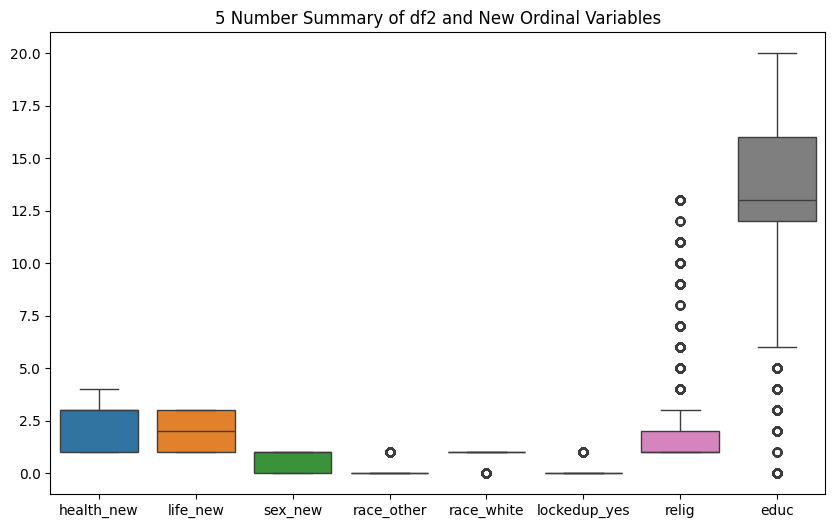

In [115]:
# boxplot showing 5 number summary of df2
plt.figure(figsize=(10,6))
sns.boxplot(data=df_new.drop(columns=['happy_new', 'year']))
plt.title('5 Number Summary of df2 and New Ordinal Variables')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of df_new')

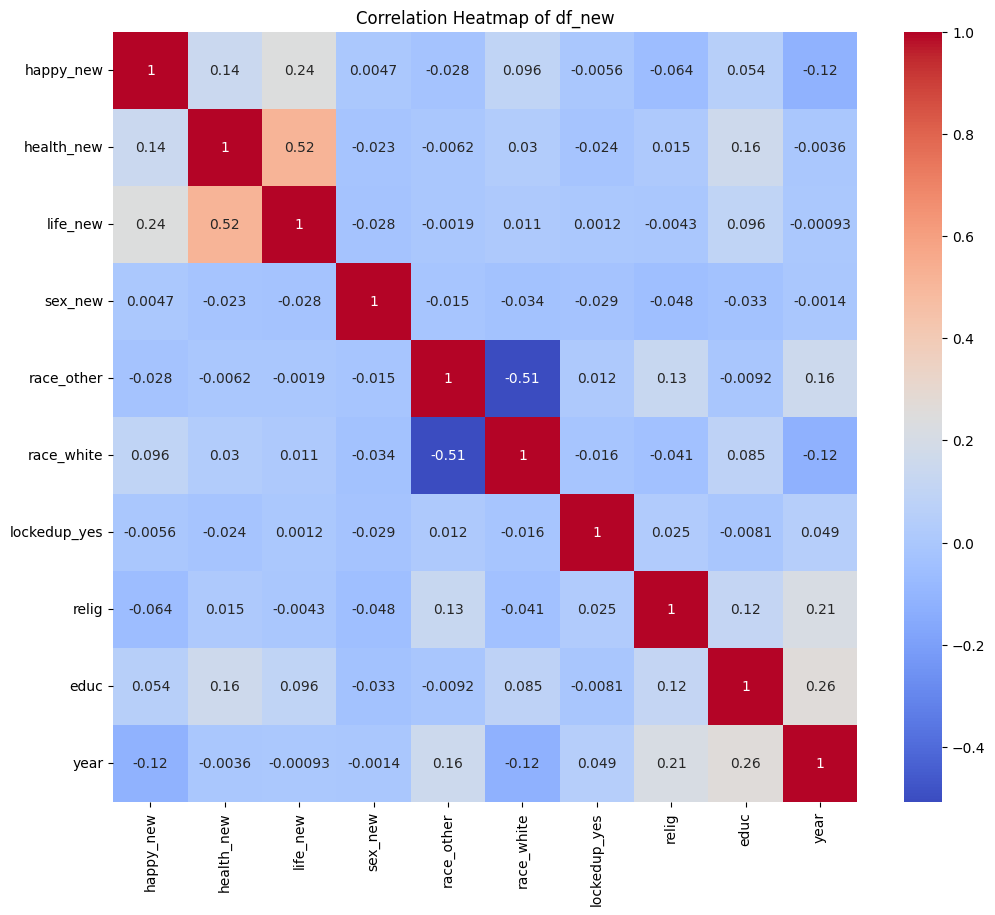

In [116]:
# correlation plot head map of df_new
# drop occ column
plt.figure(figsize=(12,10))
sns.heatmap(df_new.drop(columns=['occ']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of df_new')

Based off of the correlation matrix, there is no apparent variable that highly influences happiness in the + or - direction. Life_new received a 0.24, but since it is close to 0 we do not suspect it to mean much. 

## EDA (2 visualizations)

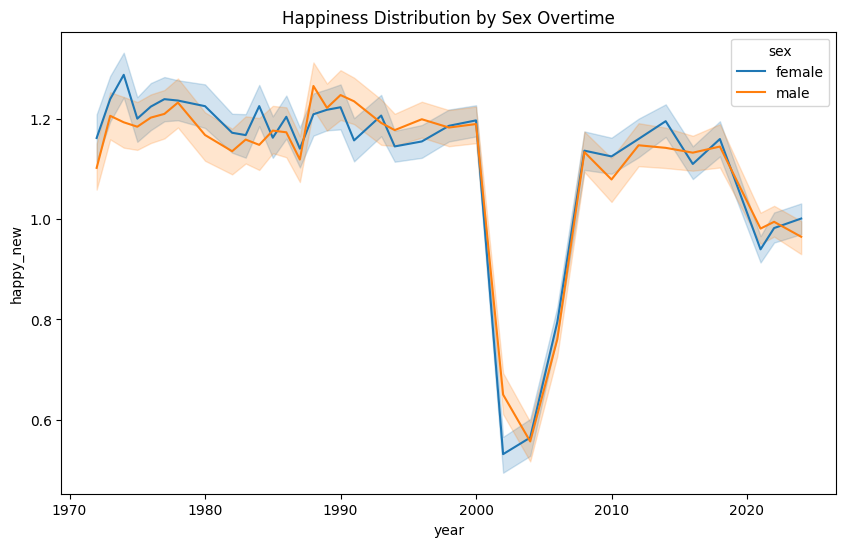

In [117]:
# happyiness distrbution by sex overtime
plt.figure(figsize=(10,6))
sns.lineplot(x='year', y='happy_new', hue='sex', data=df2)
plt.title('Happiness Distribution by Sex Overtime')
plt.show()

The figure above displays mean happiness scores (coded 0 = not too happy, 1 = pretty happy, 2 = very happy) for female and male respondents across GSS survey years from 1972 to 2024. 

From 1972 through the early 2000s, women consistently reported slightly higher average happiness than men, reproducing the female happiness advantage documented in prior literature. However, this gap narrows substantially beginning around 2006–2008, with the two groups converging by the mid-2010s — a pattern consistent with Stevenson and Wolfers' (2009) finding of declining relative female happiness in the United States. 

A notable anomaly appears in the 2002–2004 waves, where mean scores drop sharply for both sexes before rebounding; this likely reflects a methodological change in the GSS instrument rather than a true behavioral shift and warrants further investigation. Additionally, both groups show a decline in reported happiness in the 2021–2024 waves, which may reflect pandemic-era wellbeing effects compounded by the GSS transition to web-based data collection introduced in 2021.

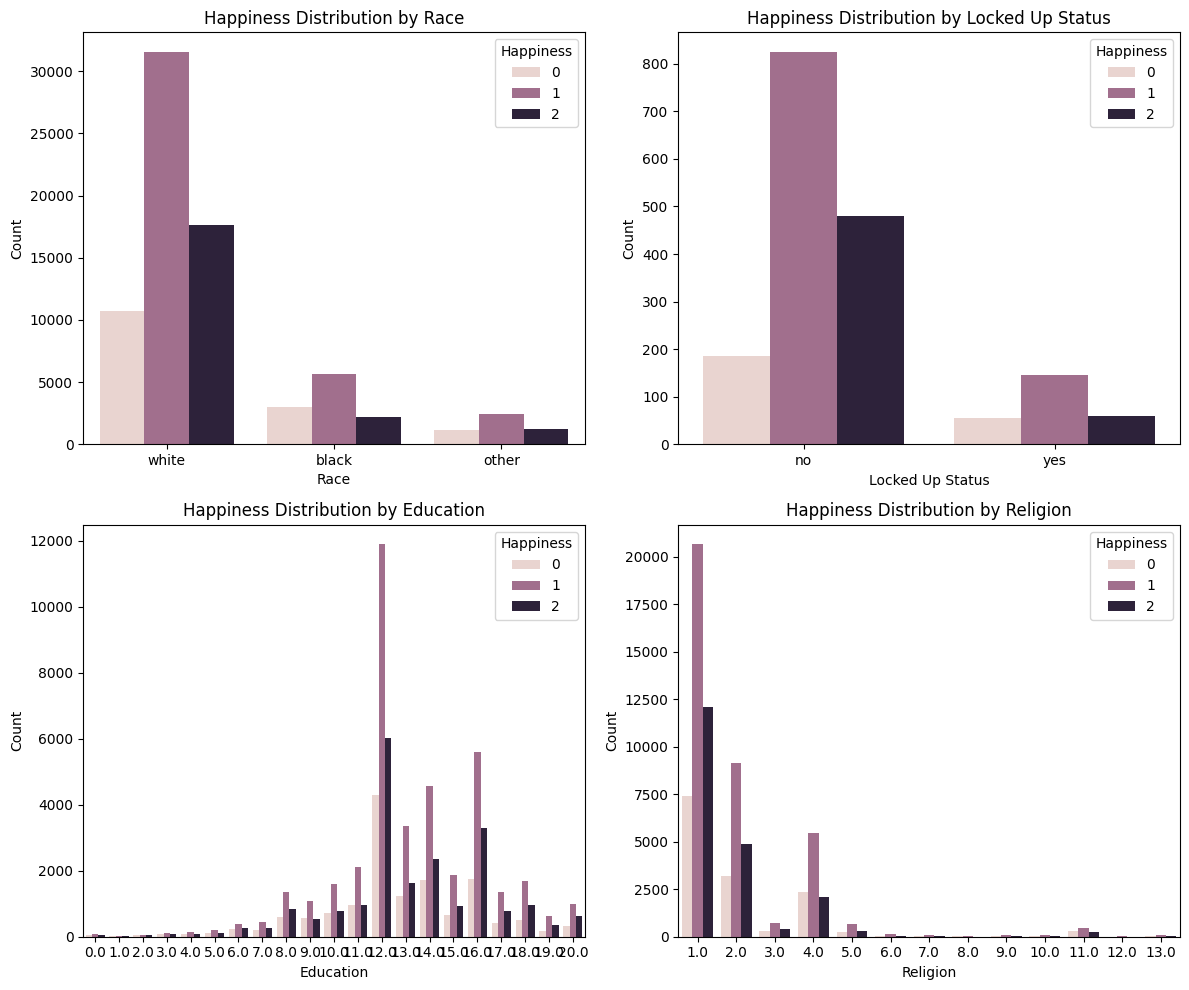

In [118]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.countplot(x='race', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.subplot(2,2,2)
sns.countplot(x='lockedup', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Locked Up Status')
plt.xlabel('Locked Up Status')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.subplot(2,2,3)
sns.countplot(x='educ', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.subplot(2,2,4)
sns.countplot(x='relig', hue='happy_new', data=df2)
plt.title('Happiness Distribution by Religion')
plt.xlabel('Religion')
plt.ylabel('Count')
plt.legend(title='Happiness')

plt.tight_layout()
plt.show()



Out of all 4 plots above, most people reported being pretty happy. 

We will need to look back at the GSS data record to find out the education level 12.0 and 1.0 religion. I am curious to know what those 2 variables are since most people reported as such (e.g., christian, teacher). 

Out of the four variables, there is not category where "very well" is out numbering the rest. This will be interesting to find as no 1 variable in the plot above or in the correlation plot a few cells above strongly influences happiness levels.

# Reflection & Potential Challenges

"Working with the GSS dataset presented several practical challenges. Feature encoding required careful thought — deciding between ordinal, binary, and one-hot encoding depended on the underlying structure of each variable, not a single blanket rule. 

The GSS also uses non-standard missing value codes rather than NaN, which required deliberate recoding before analysis. Mid-project, we recognized that marital status and age had been left out of our initial feature set. Both are theoretically important — marital status is one of the strongest predictors of happiness in the literature, and age captures life-stage effects that likely interact with sex. We also noticed a sharp anomaly in the 2002–2004 survey waves and a post-2021 decline, both of which appear tied to methodological changes in GSS data collection rather than real shifts in wellbeing. 

The biggest takeaway was that the most consequential work in a machine learning project happens before modeling — in understanding, cleaning, and deliberately constructing the dataset.

# Appendix (other EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75699 entries, 0 to 75698
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        75699 non-null  int64  
 1   id          75699 non-null  int64  
 2   sex         75568 non-null  object 
 3   race        75527 non-null  object 
 4   educ        75413 non-null  float64
 5   lockedup    1748 non-null   object 
 6   occ         75699 non-null  object 
 7   relig       71953 non-null  float64
 8   happy       70869 non-null  object 
 9   hapmar      35350 non-null  object 
 10  health      58448 non-null  object 
 11  life        46463 non-null  object 
 12  health_new  75699 non-null  int64  
 13  life_new    75699 non-null  int64  
 14  sex_new     75699 non-null  int64  
 15  happy_new   75699 non-null  int64  
dtypes: float64(2), int64(6), object(8)
memory usage: 9.2+ MB


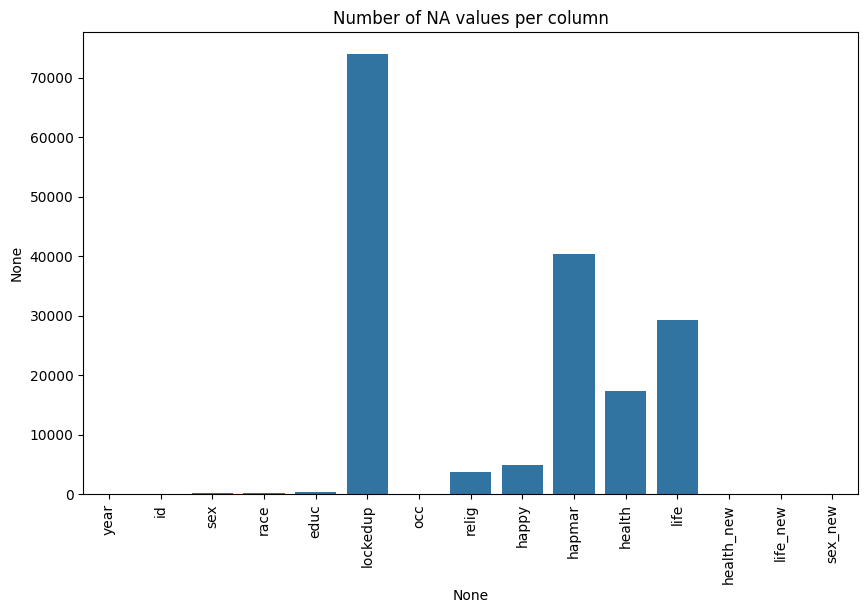

In [119]:
df2.info()
plt.figure(figsize=(10,6))
sns.barplot(x=df2.columns[:-1], y=df2.isna().sum()[:-1])
plt.xticks(rotation=90)
plt.title('Number of NA values per column')
plt.show()

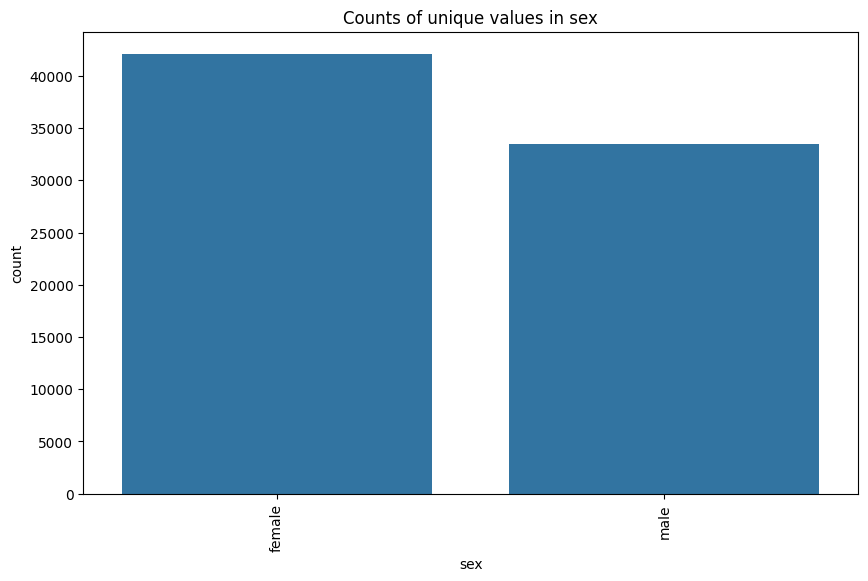

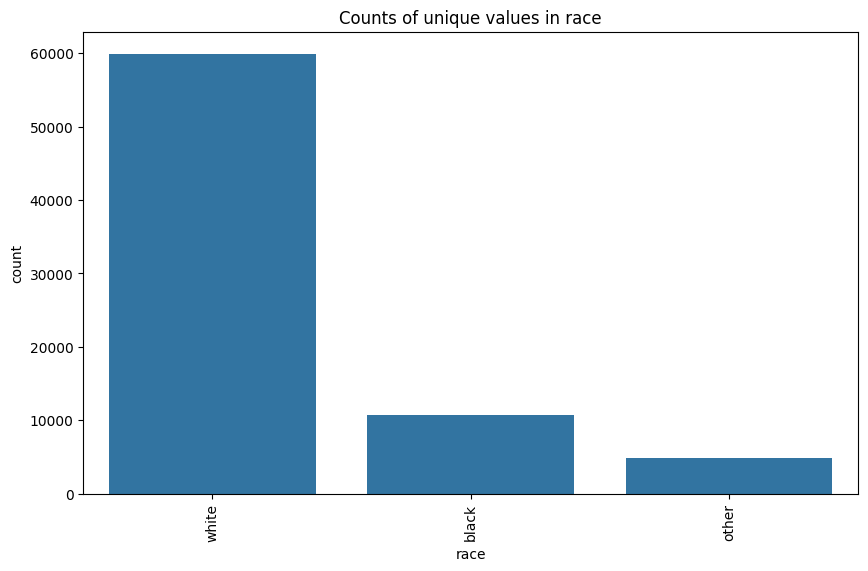

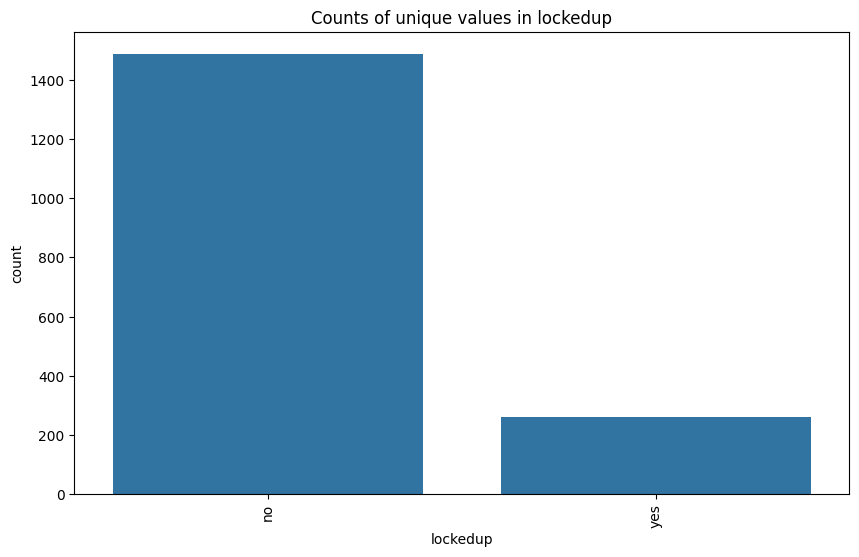

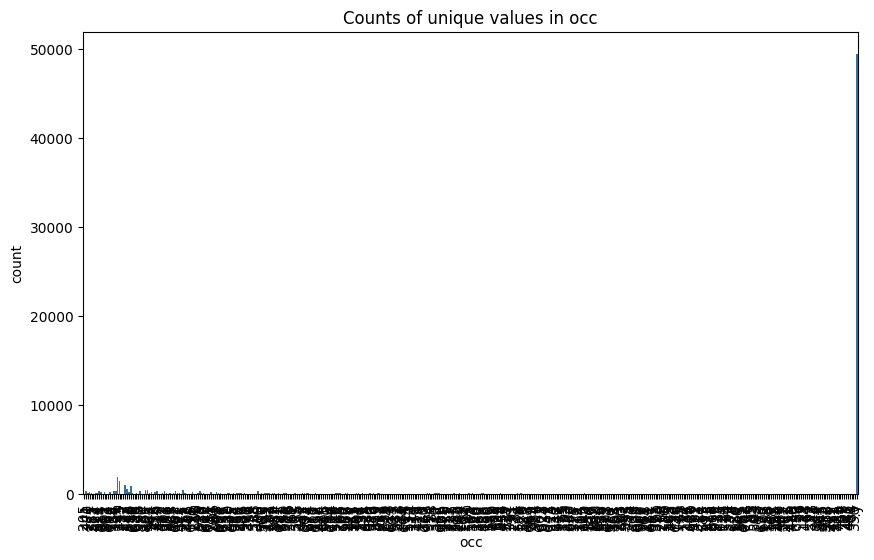

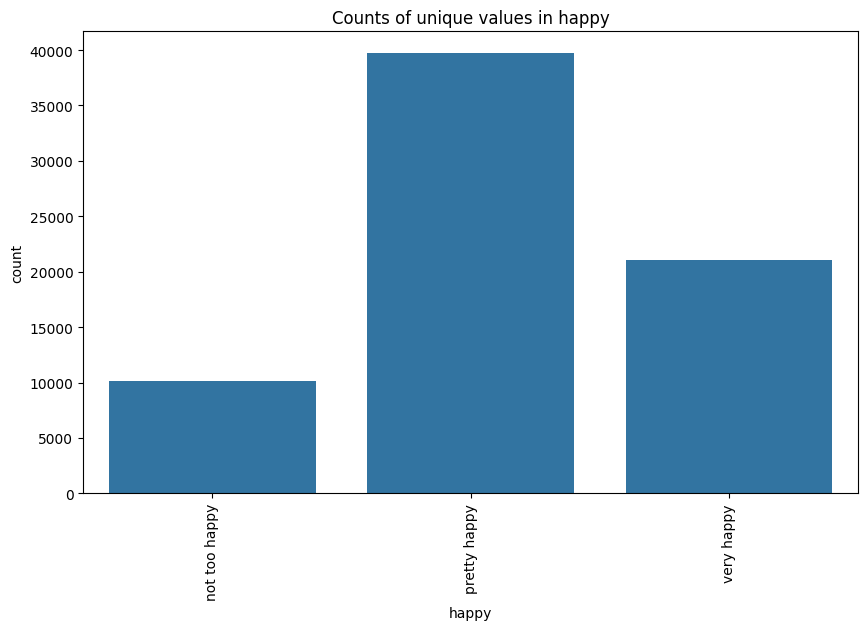

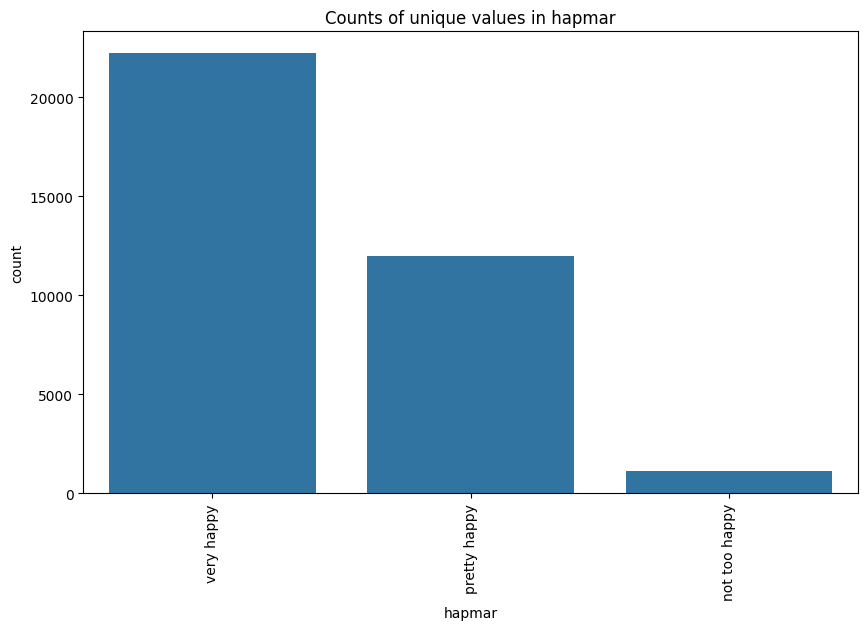

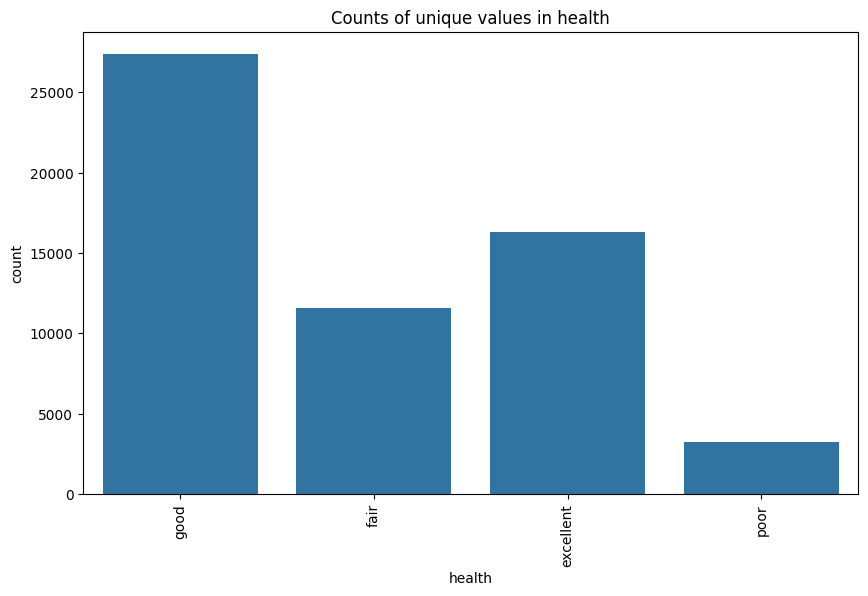

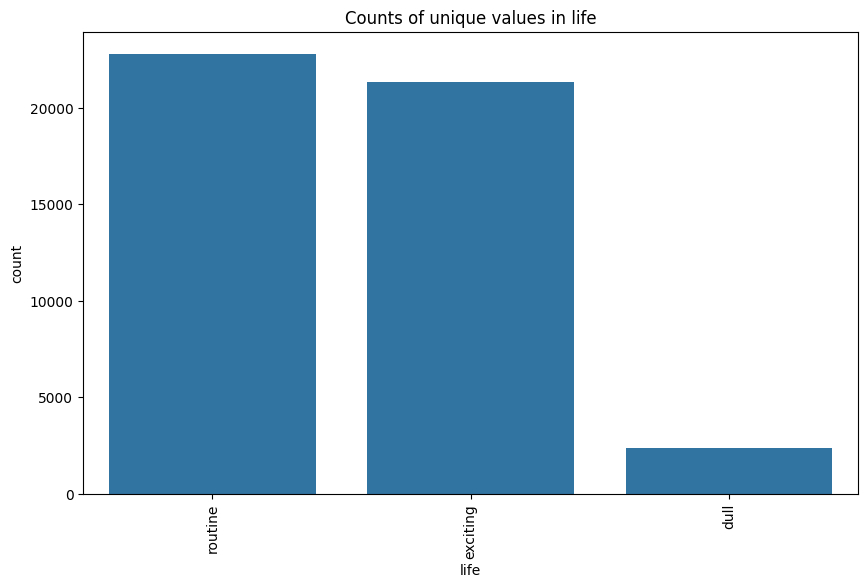

In [120]:
# for each non-numeric column in df2, make a bar plot of the counts of each unique value
for col in df2.columns:
    if df2[col].dtype == 'object':
        plt.figure(figsize=(10,6))
        sns.countplot(x=df2[col])
        plt.xticks(rotation=90)
        plt.title(f'Counts of unique values in {col}')
        plt.show()